# Investigating the Relationship Between Playtime, Experience, Age, and Subscription in Online Gaming Data
## DSCI100 
### Group 38 - Eugene, Harleen, Tim



![image](https://wallpapers.com/images/hd/minecraft-server-1920-x-1080-wallpaper-zwwd7atdapdm2ttu.jpg) 

Source: Wallpapers.com. (n.d.). https://wallpapers.com/images/hd/minecraft-server-1920-x-1080-wallpaper-zwwd7atdapdm2ttu.jpg 

## Introduction 
#### Background
Understanding player characteristics is crucial for recruiting participants and maintaining long-term engagement in video game research environments. A research group in Computer Science at UBC, led by Frank Wood, is collecting behavioural data from players through a Minecraft-based (Plaicraft) research server (UBC PLAI, 2025). Their goal is to better understand how people play, and to allocate resources such as server capacity, hardware, and licensing more efficiently. Identifying which player attributes predict newsletter subscription can help streamline recruitment and communication efforts, making this analysis directly relevant to ongoing data driven decision-making in the project.

#### Question 
We selected Question 1 as the focus of our analysis. Specifically, we aim to determine whether a player’s experience level, age, and total playtime can predict their likelihood of subscribing to the game-related newsletter. To investigate this, we used the players.csv dataset. Treating subscribe as the response variable and experience, age, and playtime as the explanatory features.

#### Dataset 
We based our analysis on players.csv dataset, which contains information on 196 unique players who interacted with the Plaicraft research server. The dataset includes 7 variables, with our outcome of interest being subscribe, a binary indicator of whether a player is signed up for the project newsletter. The explanatory variables we focus on are:
- *experience* - categorical player skill level (beginner, amateur, regular, pro, and veteran)
- *Age* - numerical age of the player
- *played_hours* - total in-game playtime recorded in hours

Additional fields in the dataset include gender, name, and hashedEmail, which is serving as a unique identifier for each player. This dataset allows us to explore whether age, experience, and gameplay duration can predict newsletter subscription status.

## Methods
### Data Wrangling & Cleaning

We began by loading the necessary packages and the player dataset containing demographic and behavioural variables. This dataset forms the basis of our predictive modeling. Next, to prepare the dataset for analysis, we first cleaned and standardized several key variables to ensure they were in the correct format for visualization and modeling. The experience variable originally appeared as text categories, so we converted it into an ordered factor with levels ranging from “Beginner” to “Veteran.” This ordering is important because experience represents a progression of skill, and the KNN method requires the categories to reflect their natural order for meaningful analysis. Next, the subscribe variable was stored as a logical TRUE/FALSE value, which cannot be used directly in classification models. To address this, we converted it into a two-level factor (“no” and “yes”), making it compatible with modeling functions and easier to interpret in figures and summary tables.

After standardizing the categorical variables, we selected only the variables relevant to our research question: age, played_hours, experience, and subscription status to create a clean dataset focused on the predictors and outcome of interest. Finally, we used drop_na() to remove any rows containing missing values in these columns. This step ensures that all observations included in the analysis are complete and prevents errors during model fitting or plotting. Together, these wrangling steps create a tidy, consistent dataset that is suitable for exploratory visualization, statistical modeling, and reproducible analysis.

In [113]:
library(tidyverse)
library(repr)
library(tidymodels)
library(cowplot)
options(repr.matrix.max.rows = 6)


players <- read_csv('players.csv')
players

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


*Table 1: Raw Data*

In [114]:
players <- players |>
  mutate(
    age = Age,
    experience = factor(experience, levels = c("Beginner", "Amateur", "Regular", "Pro", "Veteran"), ordered = TRUE),
   subscribe = factor(subscribe,levels = c(FALSE, TRUE),
      labels = c("no", "yes"))
  )
      
players_wrangled <- players |>
    select(age, played_hours, experience, subscribe) |>
    drop_na(age, played_hours)
players_wrangled

age,played_hours,experience,subscribe
<dbl>,<dbl>,<ord>,<fct>
9,30.3,Pro,yes
17,3.8,Veteran,yes
17,0.0,Veteran,no
⋮,⋮,⋮,⋮
22,0.3,Veteran,no
57,0.0,Amateur,no
17,2.3,Amateur,no


*Table 2: Wrangled Data*

### Summary Statistics for Exploratory Data Analysis

To understand the structure and distribution of the dataset, we computed summaries aligned with our planned analysis. These summaries helped us identify general player trends and assess relationships between predictors and subscription status.

In [115]:
players_summary <- players_wrangled |>
  summarise(mean_age = mean(age, na.rm = TRUE),
    mean_hours = mean(played_hours),
    number_of_players = n())
players_summary 

mean_age,mean_hours,number_of_players
<dbl>,<dbl>,<int>
21.13918,5.904639,194


*Table 3: Summary Statistics*

In [116]:
players_subscribed <- players_wrangled |>
  group_by(subscribe) |>
  summarise(
    mean_age = mean(age, na.rm = TRUE),
    mean_hours = mean(played_hours),
    n = n(), .groups = "drop")
players_subscribed

subscribe,mean_age,mean_hours,n
<fct>,<dbl>,<dbl>,<int>
no,23.7500,0.5019231,52
yes,20.1831,7.8830986,142


*Table 4: Player Subscription*

In [117]:
experience_subscription_summary <- players_wrangled |>
  group_by(experience) |>
  summarise(
    subscription_rate = (mean(subscribe == 'yes')*100),
    number_of_players = n(),
    .groups = "drop")

experience_subscription_summary

experience,subscription_rate,number_of_players
<ord>,<dbl>,<int>
Beginner,77.14286,35
Amateur,71.42857,63
Regular,80.00000,35
Pro,69.23077,13
Veteran,68.75000,48


*Table 5: Experience Summary*

First, we calculated the overall mean age, mean hours played, and total number of players in the dataset. The results show that the average player is around 21.14 years old, play time approximately 5.90 hours, and the dataset contains 194 players. These values provide a general demographic and behavioural overview and act as a baseline for comparison across subgroups.

Next, we summarized the dataset by subscription status to compare players who subscribe to the service (“yes”) with those who do not (“no”). The results reveal clear differences between these two groups:

- Non-subscribers are older on average (23.75 years) but have extremely low engagement, playing only 0.50 hours on average.

- Subscribers, in contrast, are slightly younger (20.18 years) but play dramatically more, averaging 7.88 hours.

This suggests that playtime (not age) is the distinguishing behavioural factor between subscribers and non-subscribers.

Finally,we also examined how subscription rates varied across experience levels. Beginner, Regular, and Amateur players showed the highest subscription rates (77.1%, 80.0%, and 71.4%, respectively), while Pro and Veteran players subscribed at slightly lower rates (69.2% and 68.8%). These results indicate that subscription behavior is relatively consistent across experience categories but tends to be slightly higher among mid-level players.


Together, these summary statistics show that playtime is the strongest early signal of subscription behaviour, while age and experience appear to be much weaker predictors. These initial insights help guide and justify the modeling decisions that follow in the data analysis section.

### Exploratory Visualization


To better understand patterns within the dataset and explore potential relationships relevant to player engagement, we produced a series of visualizations, each addressing a different aspect of our research question. These figures helped reveal how experience level, subscription status, and playtime differ across the player base.

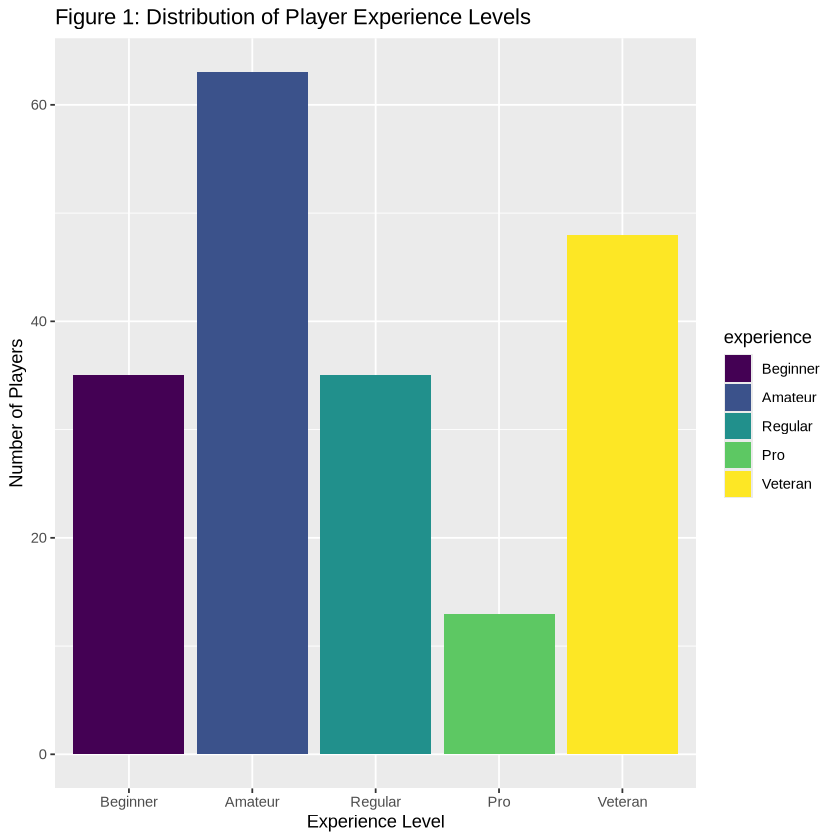

In [118]:
# FIGURE 1
experience_plot <- players_wrangled |>
ggplot(aes(x = experience, fill = experience)) +
  geom_bar() +
  labs(
    title = "Figure 1: Distribution of Player Experience Levels",
    x = "Experience Level",
    y = "Number of Players"
  )
experience_plot


Figure 1 displays the Distribution of Player Experience Levels, showing how players are spread across categories such as “Beginner,” “Intermediate,” “Advanced,” and “Expert.” This bar chart highlights that the dataset is not evenly distributed, with certain experience levels (Amateur & Veteran) being more common. Understanding this imbalance is important because it affects how much each experience group contributes to overall engagement trends.

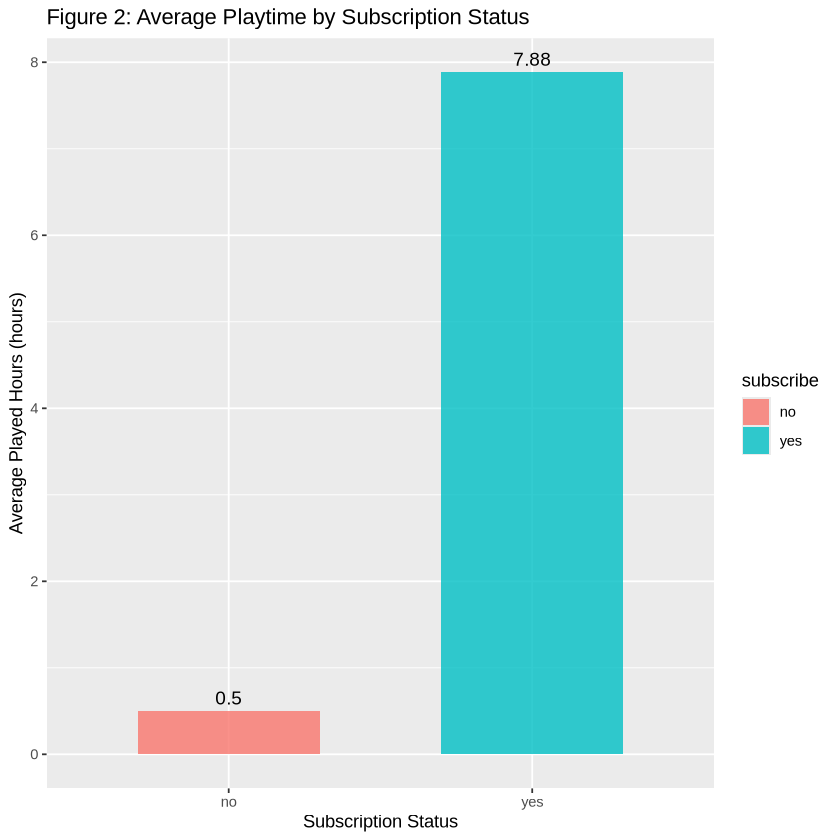

In [119]:
# FIGURE 2
subscribed_summarised <- players_wrangled |>
  group_by(subscribe) |>
  summarise(mean_hours = mean(played_hours, na.rm = TRUE))

subscribed_plot <- subscribed_summarised |>  

ggplot(aes(x = subscribe, y = mean_hours, fill = subscribe)) +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_text(aes(label = round(mean_hours, 2)), vjust = -0.5, size = 4) +
  labs(
    title = "Figure 2: Average Playtime by Subscription Status",
    x = "Subscription Status",
    y = "Average Played Hours (hours)")
subscribed_plot

Figure 2 presents the Average Playtime by Subscription Status. By summarizing mean hours played for subscribed and unsubscribed players, this visualization provides an early indication of how subscription may relate to engagement. Subscribed players show notably higher average playtime, suggesting that subscription status is associated with more consistent or longer-term play patterns.

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


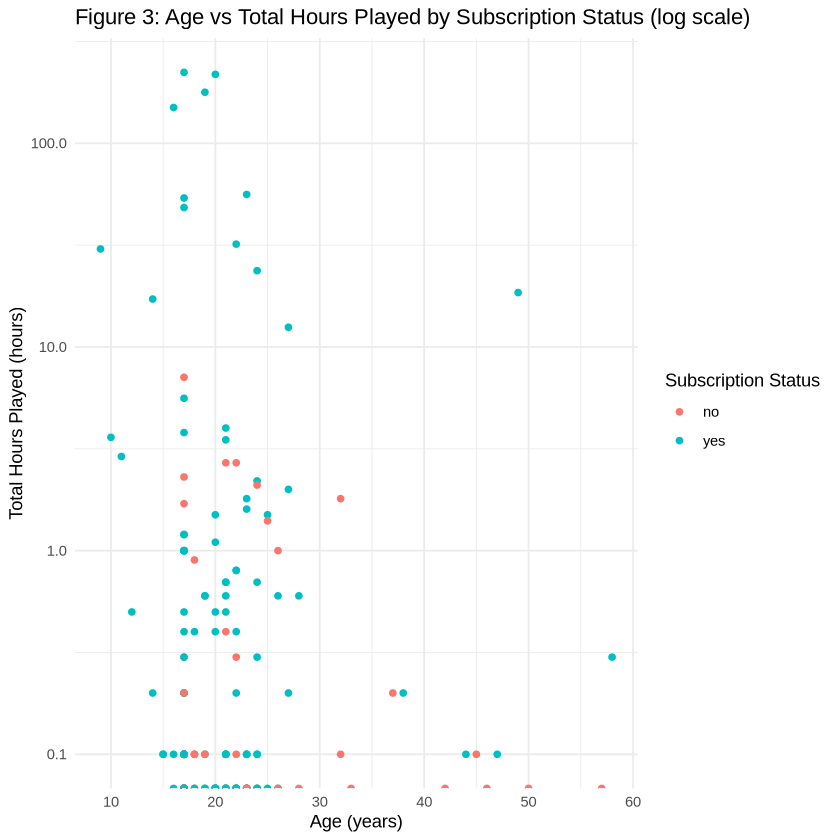

In [120]:
# FIGURE 3
age_hours_plot <- players_wrangled |>
  ggplot(aes(x = age, y = played_hours, colour = subscribe)) +
  geom_point(alpha = 1) +
scale_y_log10() +
  labs(
    title   = "Figure 3: Age vs Total Hours Played by Subscription Status (log scale)",
    x       = "Age (years)",
    y       = "Total Hours Played (hours)",
    colour  = "Subscription Status"
  ) +
  theme_minimal()

age_hours_plot

Figure 3 displays Age vs Total Hours Played (log scale), coloured by subscription status. This scatterplot highlights the wide variability in playtime across age groups and shows that subscribers generally appear at higher playtime values. The log scale makes patterns visible that would otherwise be hidden by outliers. While age itself does not show a strong linear relationship with playtime, the visualization suggests that subscription status is a more influential factor than age in determining player engagement.

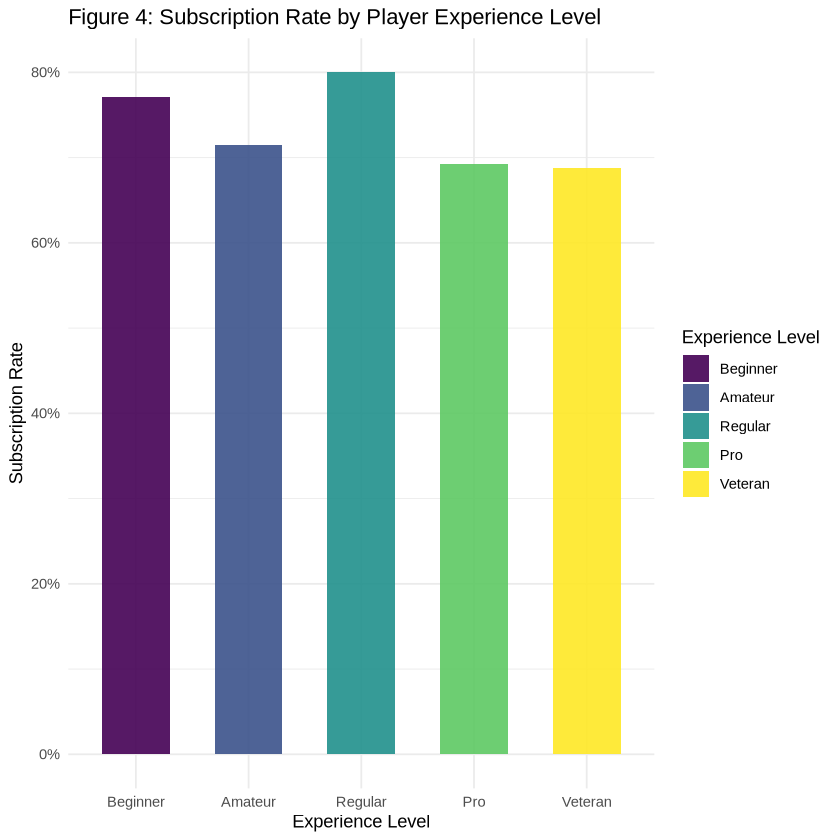

In [121]:
# FIGURE 4
experience_subscription_summary <- players_wrangled |>
  group_by(experience) |>
  summarise(
    subscription_rate = mean(as.character(subscribe) == 'yes'),
    number_of_players = n(),
    .groups = "drop"
  )

subscription_rate_plot <- experience_subscription_summary |>
  ggplot(aes(x = experience, y = subscription_rate, fill = experience)) +
  geom_col(width = 0.6, alpha = 0.9) +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = "Figure 4: Subscription Rate by Player Experience Level",
    x     = "Experience Level",
    y     = "Subscription Rate",
    fill  = "Experience Level") +
  theme_minimal()


subscription_rate_plot

Figure 4 summarizes how likely players of each experience group are to subscribe. This provides insight into whether more experienced players are more willing to invest in the game. Regular players show the highest subscription rate followed closely by Beginners and Amateurs, while Pro and Veteran players exhibit slightly lower rates. Although the differences are not extremely large, this pattern suggests that newer or moderately experienced players may be more likely to subscribe than highly experienced players. Overall, the graph indicates that experience level does have some relationship with subscription behaviour, but the variation across groups is minor.

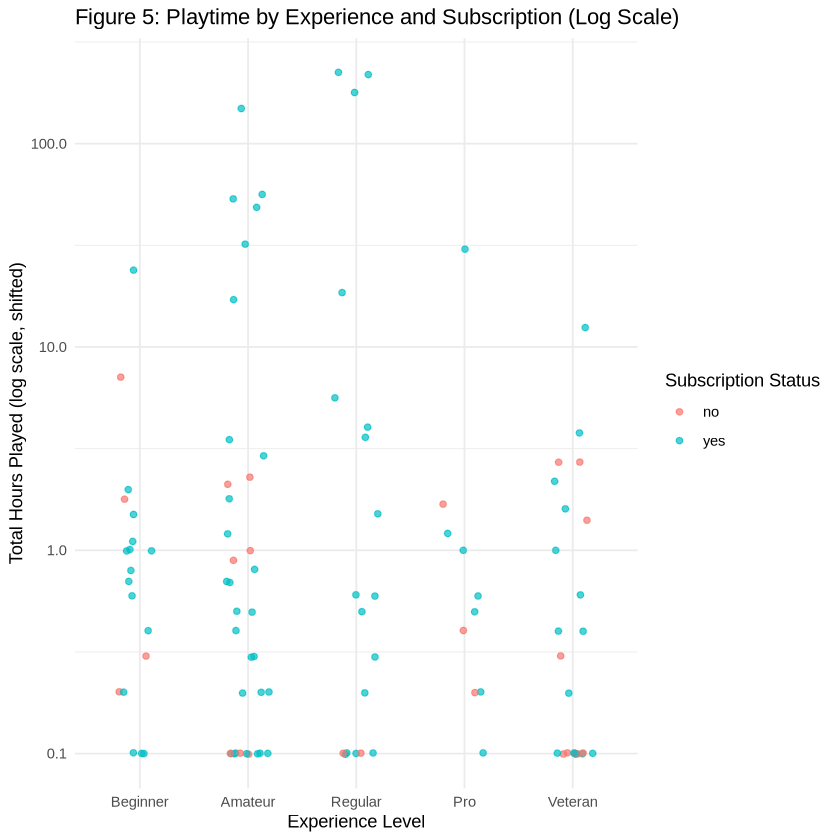

In [122]:
# FIGURE 5
playtime_experience_plot <- players_wrangled |>
  filter(played_hours != 0) |>  
  ggplot(aes(x = experience, y = played_hours, colour = subscribe)) +
  geom_jitter(alpha = 0.7, width = 0.2) +
  scale_y_log10() +
  labs(
    title = "Figure 5: Playtime by Experience and Subscription (Log Scale)",
    x = "Experience Level",
    y = "Total Hours Played (log scale, shifted)",
    colour = "Subscription Status") + theme_minimal()

playtime_experience_plot

Figure 5  shows the distribution of played hours across experience levels and subscription groups, after filtering out players with 0 hours. Using points on a log-scaled y-axis, this visualization highlights how playtime varies within and between experience categories. Subscribers consistently cluster at higher playtime values across most experience levels, reinforcing the pattern that subscription status is strongly associated with greater engagement.

Together, the five visualizations provide a clear picture of how experience level, subscription status, age, and playtime interact within the dataset. The experience distribution (Figure 1) shows that players are unevenly spread across experience levels, which helps contextualize later comparisons. Figures 2 and 3 consistently demonstrate that subscribed players engage with the game far more than non-subscribers, both in terms of average playtime and total hours played across age groups. Figures 4 and 5 further reveal that experience also plays an important role: subscription rates vary across experience levels, and subscribers consistently appear at higher playtime values within nearly every experience category. Overall, these visual patterns highlight strong relationships between subscription status, experience, and engagement, and they motivate the need for predictive modeling in the next stage of the analysis.

### Data Analysis

In this section, we build and evaluate a classification model to determine whether player characteristics can be used to predict subscription status. From the patterns identified in the visualization section, specifically the strong relationships between playtime, experience level, and subscription, we apply a k-nearest neighbours (kNN) model. kNN is an appropriate choice for this project because it is a simple, interpretable model that classifies observations based on similarity, making it well suited for behavioural data such as hours played and level of experience. The analysis below includes data splitting, preprocessing, model tuning, model fitting, and performance evaluation.

In [123]:
### SPLIT DATA INTO TRAINING AND TESTING SETS
set.seed(2025)
players_split <- players_wrangled |>
  initial_split(prop = 0.7, strata = subscribe)

players_train <- training(players_split)
players_test  <- testing(players_split)

In [124]:
### CREATE RECIPE FOR KNN MODEL
players_recipe <- recipe(subscribe ~ experience + age + played_hours,
                         data = players_train) |>
  step_integer(experience, zero_based = TRUE) |>
  step_normalize(all_predictors())

In [125]:
### CREATE KNN ENGINE 
knn_spec <- nearest_neighbor(mode = "classification",
  neighbors = tune()) |>
  set_engine("kknn")

knn_workflow <- workflow() |>
  add_recipe(players_recipe) |>
  add_model(knn_spec)

In [126]:
### TUNE TO FIND BEST K VALUE
set.seed(2025)
players_folds <- vfold_cv(players_train, v = 5, strata = subscribe)

k_grid <- grid_regular(neighbors(range = c(1, 25)), levels = 25)

knn_tuned <- tune_grid(
  knn_workflow,
  resamples = players_folds,
  grid = k_grid,
  metrics = metric_set(accuracy))

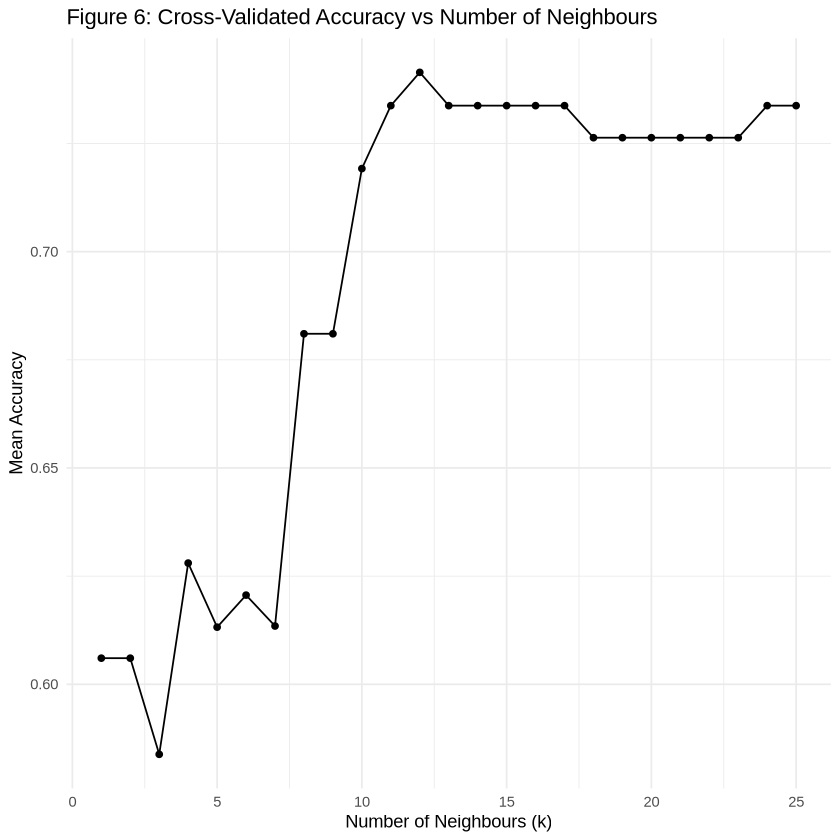

In [127]:
### PLOT K-VALUE METRICS 
accuracy_plot <- knn_tuned |>
  collect_metrics() |>
  filter(.metric == "accuracy") |>
  ggplot(aes(x = neighbors, y = mean)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Figure 6: Cross-Validated Accuracy vs Number of Neighbours",
    x = "Number of Neighbours (k)",
    y = "Mean Accuracy") +
  theme_minimal()

accuracy_plot

In [128]:
### CREATE MODEL USING BEST K VALUE
best_k <- knn_tuned |> select_best("accuracy")
best_k

final_knn_workflow <- knn_workflow |>
  finalize_workflow(best_k)

final_knn_fit <- final_knn_workflow |> fit(players_train)

neighbors,.config
<int>,<chr>
12,Preprocessor1_Model12


*Table 6: Best-fitting k value*

In [129]:
# TEST MODEL
test_predictions <- predict(final_knn_fit, players_test) |>
  bind_cols(players_test |> select(subscribe))

test_metrics <- test_predictions |>
  metric_set(accuracy, precision)(
    truth = subscribe,
    estimate = .pred_class
  )

test_metrics

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7457627
precision,binary,0.6000000


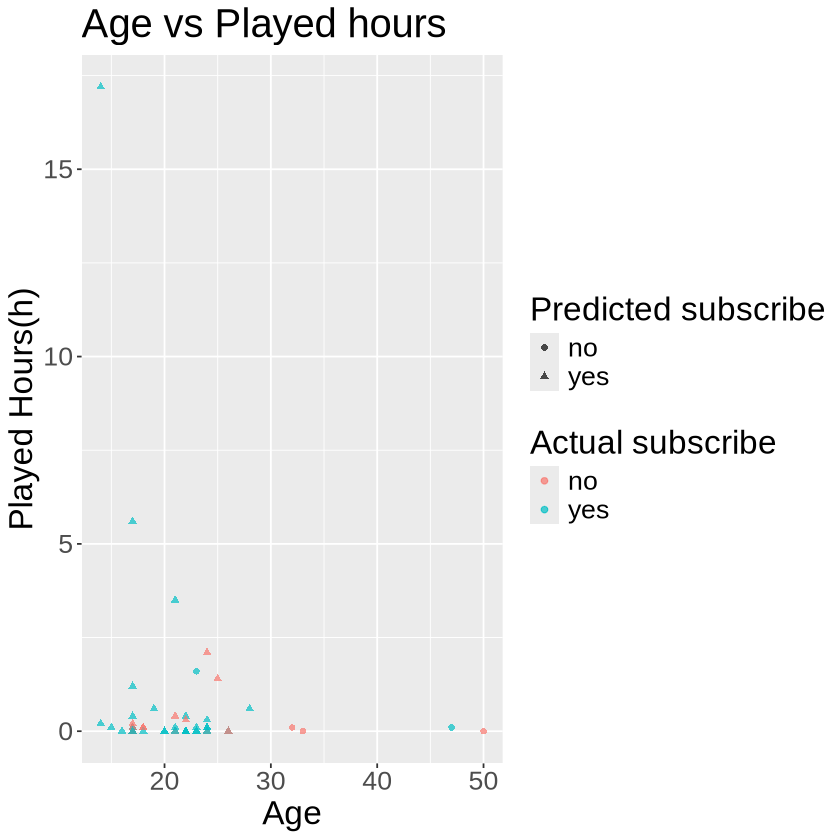

In [130]:
# TEST ANALYTICS
test_predictions_1 <- predict(final_knn_fit, players_test) |>
  bind_cols(players_test |> select(subscribe, age, played_hours))

prediction_plot <- ggplot(test_predictions_1, aes(x = age, y = played_hours)) +
  geom_point(aes(color =  subscribe, shape = .pred_class), alpha = 0.7) +
  labs(x = "Age",
       y = "Played Hours(h)",
       colour = "Actual subscribe",
       shape = "Predicted subscribe") +
  ggtitle("Age vs Played hours") +
  theme(text = element_text(size = 20))
prediction_plot

From the visualization of actual vs. predicted subscription status: blue triangles and red circles indicate correct predictions, while blue circles and red triangles represent incorrect predictions. The majority of the population is concentrated in the range of age 0–30 and played hours 0–5; within this core segment, the presence of blue circles and red triangles demonstrates that the prediction model has limitations in accurately classifying users characteristic.

*Table 7: Final Test Metrics*

### Discussion & Summary


Our data analysis using a k-nearest neighbours classification model revealed that the optimal value of k varied noticeably each time the model was retrained, and the resulting accuracy and precision also shifted across runs. This instability suggests that the model’s performance is highly sensitive to the specific partitioning of the training and testing sets, which indicates that the relationship between age, experience level, playtime, and subscription status is not strong or consistent enough for the model to make reliable predictions. Alternatively, this may also come from our sample size being too small to be able to give meaningful or consistently accurate results.

Additionally, even when the model did produce reasonably high accuracy scores—typically around 72–75%, its precision remained much lower, often close to 40–60%. This means that although the model was able to classify many players correctly overall, it struggled specifically with identifying true subscribers, frequently misclassifying non-subscribers as subscribers. The discrepancy between accuracy and precision further supports the conclusion that the patterns in our predictors are not strong enough to allow confident or targeted classification.

In other words, although our exploratory visualizations suggested that subscribed players tend to play more hours and appear somewhat differently across experience levels, the inconsistency of the optimal k and the fluctuating performance metrics show that the underlying patterns are not solid or deterministic. This was somewhat unexpected, as we initially anticipated a clearer, more stable relationship between these engagement indicators (such as total hours played) and the likelihood of subscribing. The fact that our model does not consistently identify strong predictive power suggests that these behavioural variables alone cannot reliably explain or predict subscription decisions, and therefore we are unable to confidently claim that there is a strong connection between these factors and subscription status. More specifically, we could assume that either some of these factors don't play a role in finding subscription status, or that not enough factors are being looked at.

These findings have meaningful implications. If playtime, experience, and age together do not predict subscription reliably, then game designers or platform managers seeking to increase subscription rates may need to consider additional variables not included in our dataset. The lack of a stable predictive pattern also highlights the complexity of user behaviour, showing that subscribing may depend on factors that cannot be inferred from gameplay metrics alone. Future analyses could explore whether adding more behavioural data improves the model’s ability to detect meaningful trends. Other future analyses could instead explore these 3 predictors __*individually*__ to find a pattern within subscription status, rather than looking at all 3 together as we did in this project.

It also raises broader questions about how subscription decisions form: Do players subscribe because they are already committed, or does subscribing change their engagement? Are certain personality traits or external incentives more influential than in-game behaviour? Ultimately, the variability and weakness of our model’s predictive power emphasize the need for more detailed data and more sophisticated modelling approaches to fully understand what drives subscription behaviour.

### References: 
Wallpapers.com. (n.d.). https://wallpapers.com/images/hd/minecraft-server-1920-x-1080-wallpaper-zwwd7atdapdm2ttu.jpg 

UBC PLAI, 2025. https://plai.cs.ubc.ca/ 